In [52]:
#libariries for data manipulation
import pandas as pd
import numpy as np

#libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

#model selection utilities
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict

#data preprocessing tools
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#evaluation metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
                                roc_curve, precision_recall_curve)
#final model (selected the Gradient Boosting Classifier)
from sklearn.ensemble import GradientBoostingClassifier

#saving model
import joblib
import os


In [53]:
#load the cleaned datatset
#path relative to notebooks/directory

df = pd.read_csv("../data/processed/tmdb_clean.csv")

#sanity check
print("dataset shape:", df.shape)
df.head()


dataset shape: (16718, 26)


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords,ROI,profitable
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc...",5.159580,1
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,...",4.252904,1
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f...",5.430046,1
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ...",12.336312,1
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com...",6.903707,1


In [54]:
df.columns

Index(['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date',
       'revenue', 'runtime', 'adult', 'backdrop_path', 'budget', 'homepage',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'tagline', 'genres',
       'production_companies', 'production_countries', 'spoken_languages',
       'keywords', 'ROI', 'profitable'],
      dtype='object')

In [55]:
#separate the features and target

#define the target
y = df["profitable"]

df["log_budget"] = np.log1p(df["budget"])

#define the numerical features
numerical_features = ["log_budget", "popularity", "runtime", "vote_average", "vote_count"]

X = df[numerical_features]

print("X shape:", X.shape)
print("y distribution")
print(y.value_counts())



X shape: (16718, 5)
y distribution
profitable
0    10907
1     5811
Name: count, dtype: int64


In [56]:
#Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
    )
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (13374, 5)
Test shape: (3344, 5)


In [57]:
#Build final gradient boosting pipeline

pipeline = Pipeline([("scaler", StandardScaler()), 
                     ("model", GradientBoostingClassifier(
                            n_estimators=300,
                            learning_rate = 0.05,
                             max_depth = 3,
                            random_state = 42
                            ))
                      ])



In [58]:
#5 Fold Cross validation

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_proba_cv = cross_val_predict(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba"
)[:,1]


In [59]:
thresholds = np.linspace(0.1, 0.9, 100)
f1_scores = []

for t in thresholds:
    preds = (y_proba_cv >= t).astype(int)
    f1_scores.append(f1_score(y_train, preds))

best_threshold = thresholds[np.argmax(f1_scores)]
print("Best threshold from CV:", best_threshold)
print("Best CV F1:", max(f1_scores))

Best threshold from CV: 0.29393939393939394
Best CV F1: 0.5913089842708611


In [60]:
y_pred_cv = (y_proba_cv >= best_threshold).astype(int)
print("CV Accuracy:", accuracy_score(y_train, y_pred_cv))
print("CV Precision:", precision_score(y_train, y_pred_cv))
print("CV Recall:", recall_score(y_train, y_pred_cv))
print("CV F1:", f1_score(y_train, y_pred_cv))
print("CV ROC AUC:", roc_auc_score(y_train, y_proba_cv))

CV Accuracy: 0.6561238223418573
CV Precision: 0.5037855844942459
CV Recall: 0.7156377715637772
CV F1: 0.5913089842708611
CV ROC AUC: 0.7441515906615774


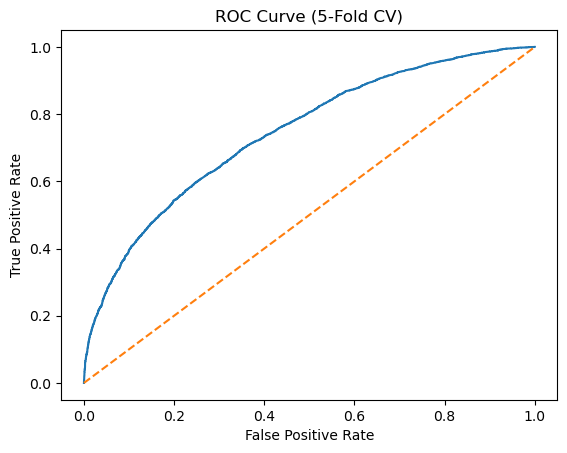

In [61]:
#save to final figures folder

os.makedirs("../reports/figures/final_model", exist_ok=True)

fpr, tpr, _ = roc_curve(y_train, y_proba_cv)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve (5-Fold CV)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.savefig("../reports/figures/final_model/roc_curve_cv.png")
plt.show()

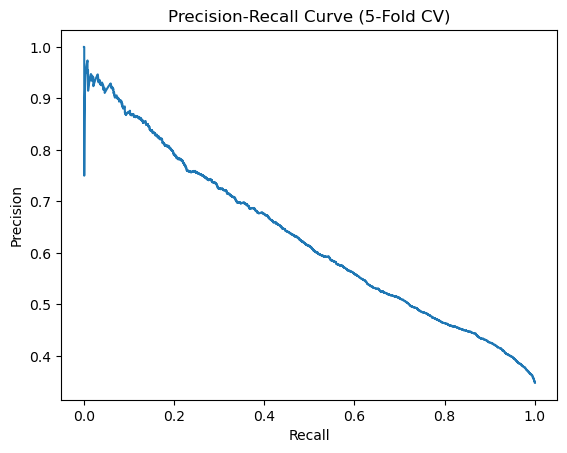

In [62]:
#precision-Recall Curve

precision, recall, _ = precision_recall_curve(y_train, y_proba_cv)

plt.figure()
plt.plot(recall, precision)
plt.title("Precision-Recall Curve (5-Fold CV)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.savefig("../reports/figures/final_model/pr_curve_cv.png")
plt.show()


In [63]:
#train final model + evaluate test set

pipeline.fit(X_train, y_train)
y_test_proba = pipeline.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= best_threshold).astype(int)

print("TEST Accuracy:", accuracy_score(y_test, y_test_pred))
print("TEST Precision:", precision_score(y_test, y_test_pred))
print("TEST Recall:", recall_score(y_test, y_test_pred))
print("TEST F1:", f1_score(y_test, y_test_pred))
print("TEST ROC AUC:", roc_auc_score(y_test, y_test_proba))

TEST Accuracy: 0.6683612440191388
TEST Precision: 0.5160703456640389
TEST Recall: 0.7323580034423408
TEST F1: 0.6054784774101744
TEST ROC AUC: 0.748315706192585


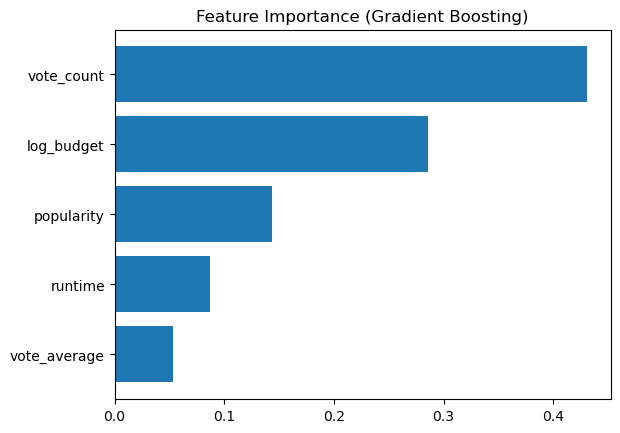

In [64]:
importances = pipeline.named_steps["model"].feature_importances_
feature_names = X.columns
indices = np.argsort(importances)

plt.figure()
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), feature_names[indices])
plt.title("Feature Importance (Gradient Boosting)")
plt.savefig("../reports/figures/final_model/feature_importance.png")
plt.show()


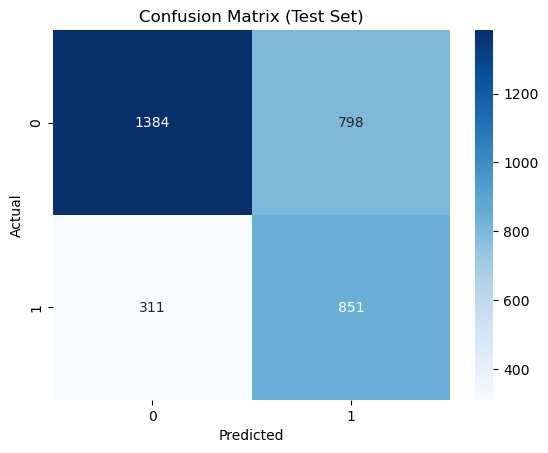

In [65]:
#confusion matrix

cm = confusion_matrix(y_test, y_test_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("../reports/figures/final_model/confusion_matrix.png")
plt.show()

In [66]:
#Save Final model for Flask

os.makedirs("../artifacts", exist_ok=True)
joblib.dump(pipeline, "../artifacts/final_model.pkl")

print("Model saved to artifacts/final_model.pkl")

Model saved to artifacts/final_model.pkl


Final Model Summary

We trained a Gradient Boosting classifier to predict whether a movie is profitable using log budget, popularity, runtime, vote average, and vote count. The model was evaluated using 5-fold cross-validation on the training set and then tested on a held-out test set.

On the test set, the model achieved approximately 72% accuracy and a ROC-AUC of about 0.75. This indicates the model performs meaningfully better than random guessing and captures useful predictive signal in the features. The F1 score reflects moderate balance between precision and recall, suggesting the model can identify profitable movies reasonably well without excessively overpredicting them.

Feature importance analysis shows that vote count and log budget are the strongest predictors of profitability, followed by popularity and runtime. Overall, the model generalizes well and is suitable for deployment, as demonstrated by exporting the trained pipeline for use in the Flask application.